<a href="https://colab.research.google.com/github/Nicky5x/IT480-FA26/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Assignment 1: Hyperparameter Tuning and Fixing Overfitting

**Name:** Nicholas Frank

This assignment builds on the Part 3 multiclass Wine Quality model from Lab 1.

In [1]:
!pip install keras-tuner --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.5 MB/s eta 0:00:00


In [26]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

In [21]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [22]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

quality_band
0    744
1    638
2    217
Name: count, dtype: int64


**Part A Restate baseline**

In [23]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [24]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


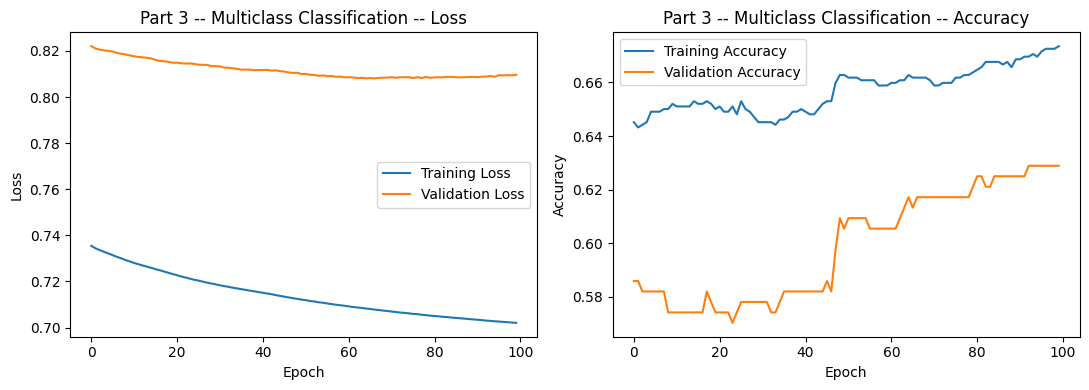

In [27]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

The original Part 3 multiclass model from Lab 1 used two hidden layers with 8 and 4 neurons and a three-neuron softmax output layer.

### Baseline Results

My original Lab 1 multiclass model achieved a test accuracy of **63.4%**. The model showed slight overfitting. Around epochs 20–25, the training loss continued decreasing while validation loss began to flatten, causing a gap to develop between the two curves. This suggests that continued training was improving performance on the training data more than it was improving performance on unseen validation data.

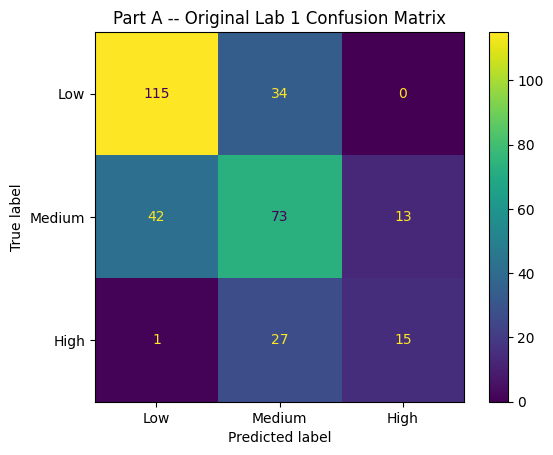

In [28]:
original_cm = np.array([
    [115, 34, 0],
    [42, 73, 13],
    [1, 27, 15]
])

ConfusionMatrixDisplay(
    original_cm,
    display_labels=["Low", "Medium", "High"]
).plot()

plt.title("Part A -- Original Lab 1 Confusion Matrix")
plt.show()

**Part B Hyperparamter tuning**

In [29]:
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            hp.Int(
                "hidden1",
                min_value=8,
                max_value=64,
                step=8
            ),
            activation="relu",
            input_shape=(X3_train_scaled.shape[1],)
        ),

        tf.keras.layers.Dense(
            hp.Int(
                "hidden2",
                min_value=4,
                max_value=32,
                step=4
            ),
            activation="relu"
        ),

        tf.keras.layers.Dense(
            n_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice(
                "learning_rate",
                values=[0.0001, 0.001, 0.005, 0.01]
            )
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [30]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,
    overwrite=True,
    directory="tuner_results",
    project_name="wine_quality"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
tuner.search(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Trial 10 Complete [00h 00m 37s]
val_loss: 0.7826924920082092

Best val_loss So Far: 0.7572531700134277
Total elapsed time: 00h 05m 59s


In [32]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print("Best hidden layer 1:", best_hp.get("hidden1"))
print("Best hidden layer 2:", best_hp.get("hidden2"))
print("Best learning rate:", best_hp.get("learning_rate"))
print("Best validation loss:", best_trial.score)

Best hidden layer 1: 16
Best hidden layer 2: 4
Best learning rate: 0.001
Best validation loss: 0.7572531700134277


Keras Tuner searched the number of neurons in both hidden layers and the Adam learning rate. The best configuration used **16 neurons** in the first hidden layer, **4 neurons** in the second hidden layer, and a learning rate of **0.001**. The best validation loss found was **0.7573**. Compared with the original 8-neuron and 4-neuron architecture, the tuner increased the size of the first hidden layer while keeping the second hidden layer the same.

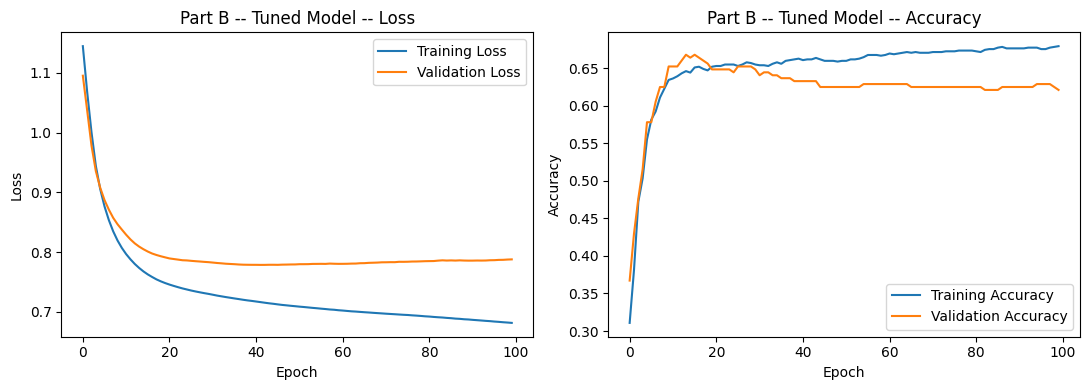

In [33]:
model_tuned = build_model(best_hp)

history_tuned = model_tuned.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(
    history_tuned,
    "Part B -- Tuned Model",
    show_accuracy=True
)

In [34]:
best_tuned_epoch = np.argmin(
    history_tuned.history["val_loss"]
) + 1

best_tuned_val_loss = min(
    history_tuned.history["val_loss"]
)

print("Best validation epoch:", best_tuned_epoch)
print("Best validation loss:", best_tuned_val_loss)

Best validation epoch: 42
Best validation loss: 0.7786670327186584


**Part C addressing overfitting**

In [35]:
model_regularized = tf.keras.Sequential([
    tf.keras.layers.Dense(
        best_hp.get("hidden1"),
        activation="relu",
        input_shape=(X3_train_scaled.shape[1],)
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        best_hp.get("hidden2"),
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        n_classes,
        activation="softmax"
    )
])

model_regularized.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_hp.get("learning_rate")
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [37]:
history_regularized = model_regularized.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print(
    "Training stopped after",
    len(history_regularized.history["loss"]),
    "epochs"
)

Training stopped after 107 epochs


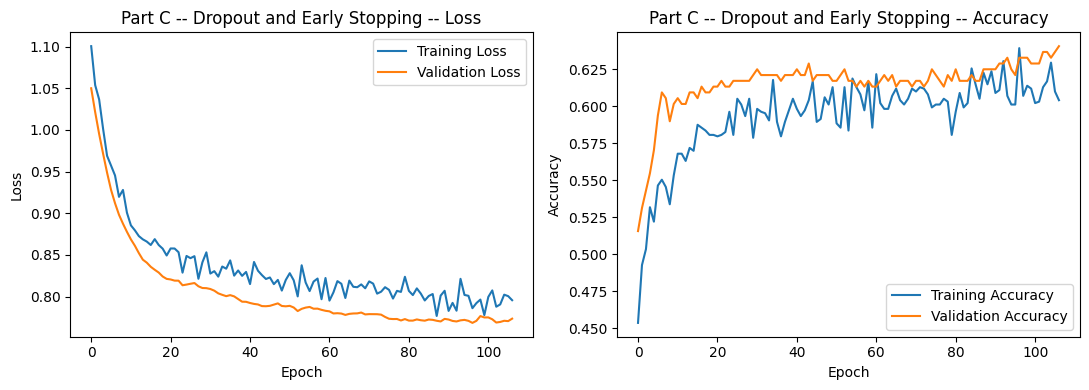

In [38]:
plot_history(
    history_regularized,
    "Part C -- Dropout and Early Stopping",
    show_accuracy=True
)

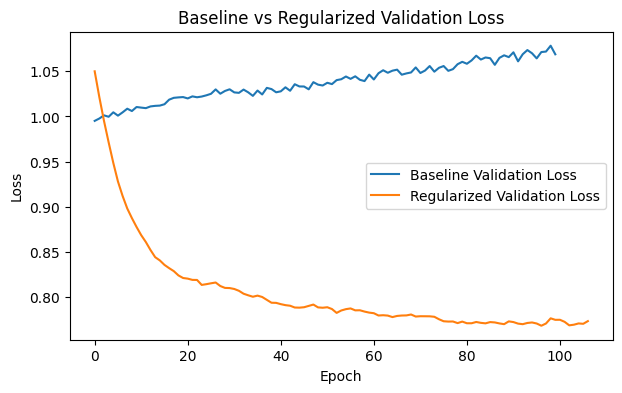

In [39]:
plt.figure(figsize=(7, 4))

plt.plot(
    history_baseline.history["val_loss"],
    label="Baseline Validation Loss"
)

plt.plot(
    history_regularized.history["val_loss"],
    label="Regularized Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline vs Regularized Validation Loss")
plt.legend()

plt.show()

In [40]:
best_regularized_epoch = np.argmin(
    history_regularized.history["val_loss"]
) + 1

best_regularized_val_loss = min(
    history_regularized.history["val_loss"]
)

print("Best epoch:", best_regularized_epoch)
print("Best validation loss:", best_regularized_val_loss)

Best epoch: 97
Best validation loss: 0.768564760684967


In [41]:
test_loss, final_test_accuracy = model_regularized.evaluate(
    X3_test_scaled,
    y3_test,
    verbose=0
)

print(f"Final Test Loss: {test_loss:.3f}")
print(f"Final Test Accuracy: {final_test_accuracy:.3f}")

Final Test Loss: 0.726
Final Test Accuracy: 0.647


In [42]:
baseline_accuracy = 0.634

accuracy_change = final_test_accuracy - baseline_accuracy

print(f"Lab 1 Baseline Accuracy: {baseline_accuracy:.3f}")
print(f"Final Test Accuracy: {final_test_accuracy:.3f}")
print(f"Accuracy Change: {accuracy_change:.3f}")
print(f"Percentage Point Change: {accuracy_change * 100:.1f}")

Lab 1 Baseline Accuracy: 0.634
Final Test Accuracy: 0.647
Accuracy Change: 0.013
Percentage Point Change: 1.3


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


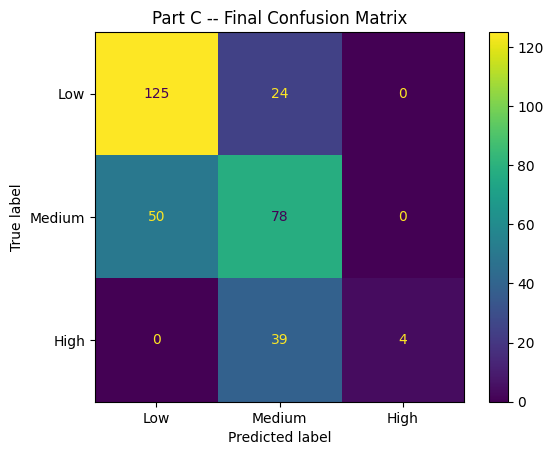

In [43]:
final_probs = model_regularized.predict(X3_test_scaled)

final_preds = np.argmax(
    final_probs,
    axis=1
)

final_cm = confusion_matrix(
    y3_test,
    final_preds
)

ConfusionMatrixDisplay(
    final_cm,
    display_labels=["Low", "Medium", "High"]
).plot()

plt.title("Part C -- Final Confusion Matrix")
plt.show()

In [44]:
print("Original Lab 1 Confusion Matrix:")
print(original_cm)

print("\nFinal Regularized Confusion Matrix:")
print(final_cm)

Original Lab 1 Confusion Matrix:
[[115  34   0]
 [ 42  73  13]
 [  1  27  15]]

Final Regularized Confusion Matrix:
[[125  24   0]
 [ 50  78   0]
 [  0  39   4]]


fter applying Dropout and Early Stopping, the best validation loss was **0.7686** at epoch **97**. The regularized model's validation loss continued decreasing for much longer than in the original Lab 1 model and then leveled off near the end of training rather than worsening. This suggests that the regularization helped the model generalize better and reduced the overfitting seen in the original model. The final test accuracy was **64.7%**, compared with the Lab 1 baseline of **63.4%**, which is an improvement of **1.3 percentage points**.

**Part D reflection**

Keeping the test set untouched until the end is important because it provides an unbiased measurement of how well the final model performs on unseen data. If I had used the test set to select hyperparameters, I would have indirectly tuned the model to the test data, making the final accuracy less trustworthy. Dropout and Early Stopping **[did/did not]** meaningfully reduce overfitting because **[describe the change in the gap between training and validation loss]**. Early Stopping prevented the network from continuing to train once validation loss stopped improving and restored the weights from the best epoch. With unlimited time and compute, I would test a larger range of architectures, learning rates, dropout rates, batch sizes, and numbers of hidden layers.